# Employee Attrition Prediction
### Week 2 Internship Project

Using the IBM HR Analytics dataset to predict which employees are likely to leave the company.


## Task 1 - Data Loading and Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("HR_Attrition.csv")
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
print("Shape:", df.shape)

Shape: (1470, 35)


In [4]:
# checking the target column
print(df["Attrition"].value_counts())
print()
attrition_pct = df["Attrition"].value_counts(normalize=True) * 100
print(attrition_pct)

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [5]:
# how many numeric vs categorical
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

Numeric columns: 26
Categorical columns: 9


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

**Observation:** The attrition rate is around 16%, meaning only about 1 in 6 employees left. 
The dataset is imbalanced - most employees stayed. This is important because a model that just 
predicts "No" for everyone would still be 84% accurate, which is misleading. We need to handle this properly.

## Task 2 - Data Cleaning and Preprocessing

In [8]:
# these columns are either IDs or have the same value for every row - useless for prediction
cols_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df = df.drop(columns=cols_drop)
print("dropped:", cols_drop)
print("new shape:", df.shape)

dropped: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
new shape: (1470, 31)


In [9]:
# converting Yes/No to 1/0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [10]:
# one hot encoding for categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("encoding these columns:", cat_cols)

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("shape after encoding:", df.shape)

encoding these columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
shape after encoding: (1470, 45)


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("X shape:", X_scaled.shape)
print("y shape:", y.shape)

X shape: (1470, 44)
y shape: (1470,)


## Task 3 - EDA (Exploratory Data Analysis)

In [12]:
# reloading original for EDA so i have the readable labels
df_raw = pd.read_csv("HR_Attrition.csv")
df_raw['left'] = df_raw['Attrition'].map({'Yes': 1, 'No': 0})

In [13]:
# attrition by department
dept_attr = df_raw.groupby('Department')['left'].mean() * 100
dept_attr = dept_attr.sort_values(ascending=False).round(1)
print("Attrition % by Department:")
print(dept_attr)

Attrition % by Department:
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: left, dtype: float64


In [14]:
# attrition by job role
role_attr = df_raw.groupby('JobRole')['left'].mean() * 100
role_attr = role_attr.sort_values(ascending=False).round(1)
print("Attrition % by Job Role:")
print(role_attr)

Attrition % by Job Role:
JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Manufacturing Director        6.9
Healthcare Representative     6.9
Manager                       4.9
Research Director             2.5
Name: left, dtype: float64


In [15]:
# income comparison
print("Avg income - employees who left:", round(df_raw[df_raw['Attrition']=='Yes']['MonthlyIncome'].mean(), 0))
print("Avg income - employees who stayed:", round(df_raw[df_raw['Attrition']=='No']['MonthlyIncome'].mean(), 0))

Avg income - employees who left: 4787.0
Avg income - employees who stayed: 6833.0


In [16]:
# work life balance
wlb = df_raw.groupby('WorkLifeBalance')['left'].mean() * 100
print("Attrition by Work-Life Balance rating (1=bad, 4=best):")
print(wlb.round(1))

Attrition by Work-Life Balance rating (1=bad, 4=best):
WorkLifeBalance
1    31.2
2    16.9
3    14.2
4    17.6
Name: left, dtype: float64


In [17]:
# tenure groups
df_raw['tenure_group'] = pd.cut(df_raw['YearsAtCompany'],
                                 bins=[0,2,5,10,20,40],
                                 labels=['0-2','3-5','6-10','11-20','20+'])

tenure_attr = df_raw.groupby('tenure_group', observed=True)['left'].mean() * 100
print("Attrition % by Years at Company:")
print(tenure_attr.round(1))

Attrition % by Years at Company:
tenure_group
0-2      28.9
3-5      13.8
6-10     12.3
11-20     6.7
20+      12.1
Name: left, dtype: float64


**Insights from EDA:**

1. Sales department has the highest attrition at around 20.6% - almost 1 in 5 employees leave
2. Sales Representatives have a 39.8% exit rate - the highest of any role
3. Employees who left earned on average $4,787/month vs $6,832 for those who stayed - a $2000 gap
4. Employees with Work-Life Balance rating of 1 (bad) leave at 31.3% - nearly double the average
5. New employees (0-2 years) leave at 33% - the critical window for retention is the first 2 years


## Task 4 - Model Training

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1176
Test size: 294


In [19]:
# logistic regression - simplest model, good starting point
# class_weight=balanced tells the model to treat both classes equally
# because our data has way more "stayed" than "left"
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:,1]
print("Logistic Regression done")

Logistic Regression done


In [20]:
# random forest
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', 
                                    random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:,1]
print("Random Forest done")

Random Forest done


In [21]:
# gradient boosting
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                        max_depth=3, subsample=0.8, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
gb_probs = gb_model.predict_proba(X_test)[:,1]
print("Gradient Boosting done")

Gradient Boosting done


## Task 5 - Model Evaluation

In [22]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             f1_score, precision_score, recall_score)

def get_scores(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Precision': round(precision_score(y_true, y_pred), 3),
        'Recall': round(recall_score(y_true, y_pred), 3),
        'F1': round(f1_score(y_true, y_pred), 3),
        'ROC-AUC': round(roc_auc_score(y_true, y_prob), 3)
    }

comparison = pd.DataFrame([
    get_scores('Logistic Regression', y_test, lr_preds, lr_probs),
    get_scores('Random Forest',       y_test, rf_preds, rf_probs),
    get_scores('Gradient Boosting',   y_test, gb_preds, gb_probs)
]).set_index('Model')

comparison

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


,Precision,Recall,F1,ROC-AUC
Model,,,,
Logistic Regression,0.341,0.617,0.439,0.799
Random Forest,0.571,0.085,0.148,0.772
Gradient Boosting,0.600,0.191,0.290,0.811


In [23]:
# logistic regression has the best recall which matters more here
# recall = out of all employees who actually left, how many did we catch?
# missing someone who leaves is worse than a false alarm for HR

print("Logistic Regression - detailed report:")
print(classification_report(y_test, lr_preds, target_names=['Stayed', 'Left']))

Logistic Regression - detailed report:
              precision    recall  f1-score   support

      Stayed       0.91      0.77      0.84       247
        Left       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294



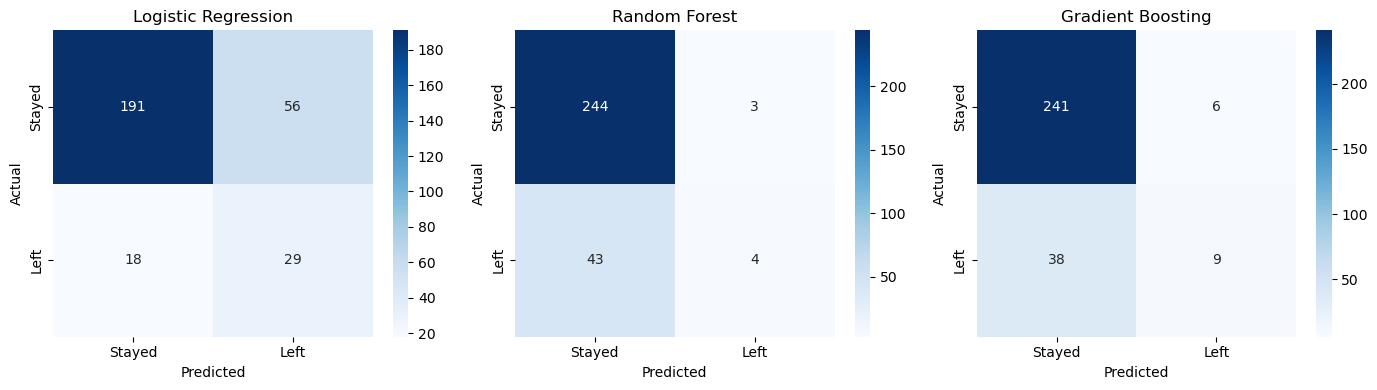

In [24]:
import os
os.makedirs('charts', exist_ok=True)

# confusion matrix for all 3
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, preds) in zip(axes, [
    ('Logistic Regression', lr_preds),
    ('Random Forest', rf_preds),
    ('Gradient Boosting', gb_preds)
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Left'],
                yticklabels=['Stayed', 'Left'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [25]:
# feature importance from gradient boosting
# using GB here because it gives cleaner feature importance scores
importances = pd.Series(gb_model.feature_importances_, index=X.columns)
top10 = importances.nlargest(10).sort_values()

print("Top 10 features:")
print(top10.sort_values(ascending=False).round(4))

Top 10 features:
MonthlyIncome              0.1054
OverTime_Yes               0.0906
Age                        0.0820
TotalWorkingYears          0.0790
DailyRate                  0.0593
NumCompaniesWorked         0.0466
StockOptionLevel           0.0448
DistanceFromHome           0.0409
EnvironmentSatisfaction    0.0401
YearsWithCurrManager       0.0376
dtype: float64


## Task 6 - Charts

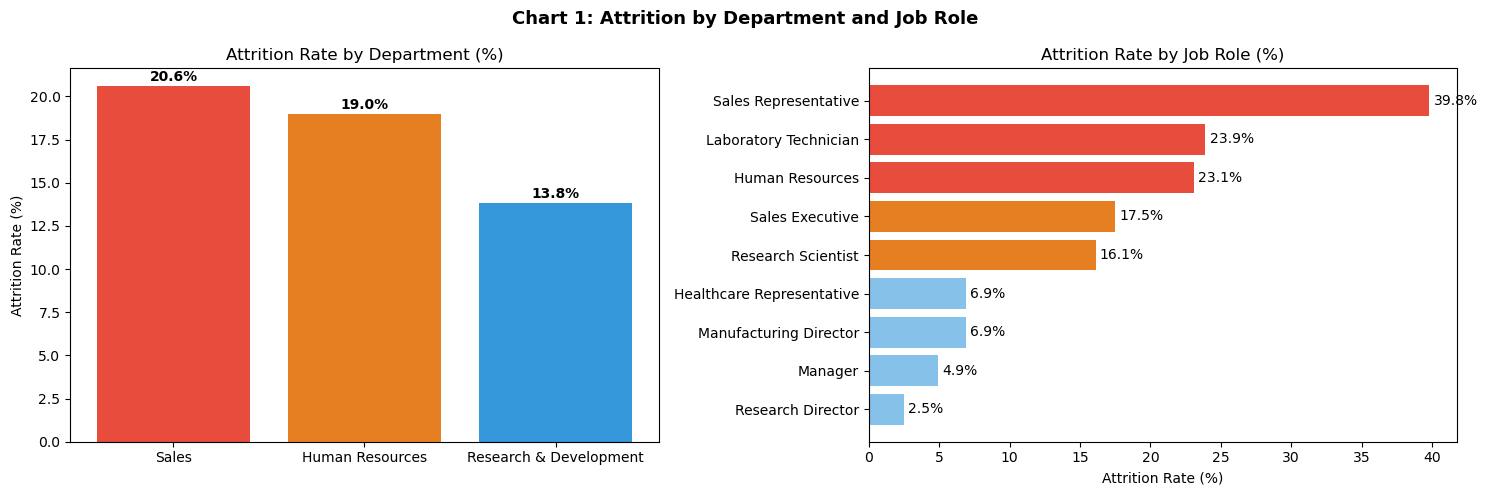

In [26]:
# Chart 1 - attrition by department and job role
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# department
dept_df = dept_attr.reset_index()
axes[0].bar(dept_df['Department'], dept_df['left'], color=['#e74c3c','#e67e22','#3498db'])
axes[0].set_title('Attrition Rate by Department (%)')
axes[0].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(dept_df['left']):
    axes[0].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

# job role
role_df = role_attr.reset_index().sort_values('left')
bar_colors = ['#e74c3c' if v > 20 else '#e67e22' if v > 10 else '#85c1e9' 
              for v in role_df['left']]
axes[1].barh(role_df['JobRole'], role_df['left'], color=bar_colors)
axes[1].set_title('Attrition Rate by Job Role (%)')
axes[1].set_xlabel('Attrition Rate (%)')
for i, v in enumerate(role_df['left']):
    axes[1].text(v + 0.3, i, f'{v}%', va='center')

plt.suptitle('Chart 1: Attrition by Department and Job Role', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart1_dept_role.png', dpi=150, bbox_inches='tight')
plt.show()

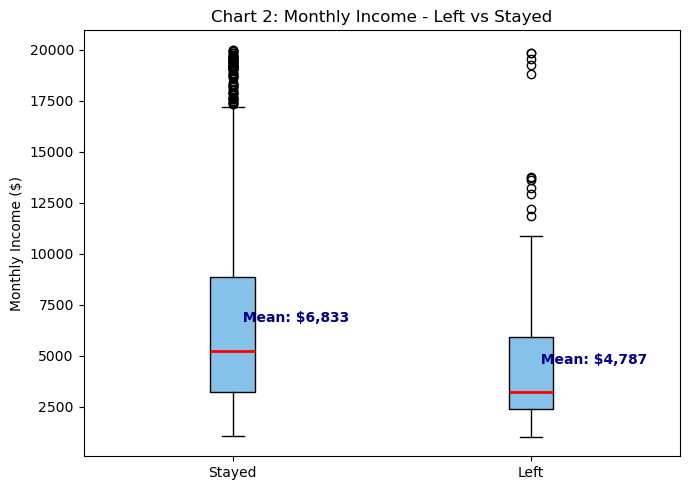

In [27]:
# Chart 2 - income boxplot
fig, ax = plt.subplots(figsize=(7, 5))

left_income = df_raw[df_raw['Attrition'] == 'Yes']['MonthlyIncome']
stayed_income = df_raw[df_raw['Attrition'] == 'No']['MonthlyIncome']

ax.boxplot([stayed_income, left_income], labels=['Stayed', 'Left'],
           patch_artist=True,
           boxprops=dict(facecolor='#85c1e9'),
           medianprops=dict(color='red', linewidth=2))

ax.set_title('Chart 2: Monthly Income - Left vs Stayed')
ax.set_ylabel('Monthly Income ($)')

# add mean labels
for i, (data, label) in enumerate([(stayed_income, 'Stayed'), (left_income, 'Left')], 1):
    ax.text(i, data.mean(), f'  Mean: ${data.mean():,.0f}', 
            va='center', fontweight='bold', color='darkblue')

plt.tight_layout()
plt.savefig('charts/chart2_income.png', dpi=150, bbox_inches='tight')
plt.show()

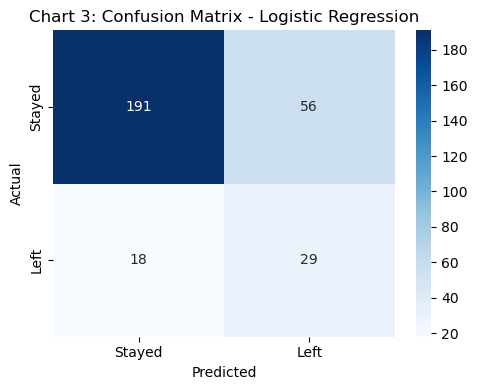

In [28]:
# Chart 3 - confusion matrix heatmap for best model (LR)
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'],
            ax=ax)
ax.set_title('Chart 3: Confusion Matrix - Logistic Regression')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('charts/chart3_cm_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

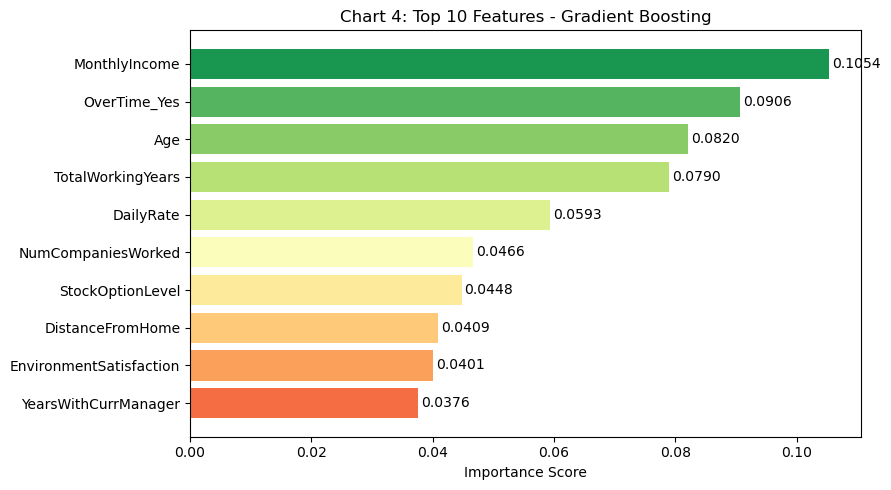

In [29]:
# Chart 4 - top 10 feature importances
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top10)))
ax.barh(top10.index, top10.values, color=colors)
ax.set_xlabel('Importance Score')
ax.set_title('Chart 4: Top 10 Features - Gradient Boosting')
for i, v in enumerate(top10.values):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.savefig('charts/chart4_features.png', dpi=150, bbox_inches='tight')
plt.show()

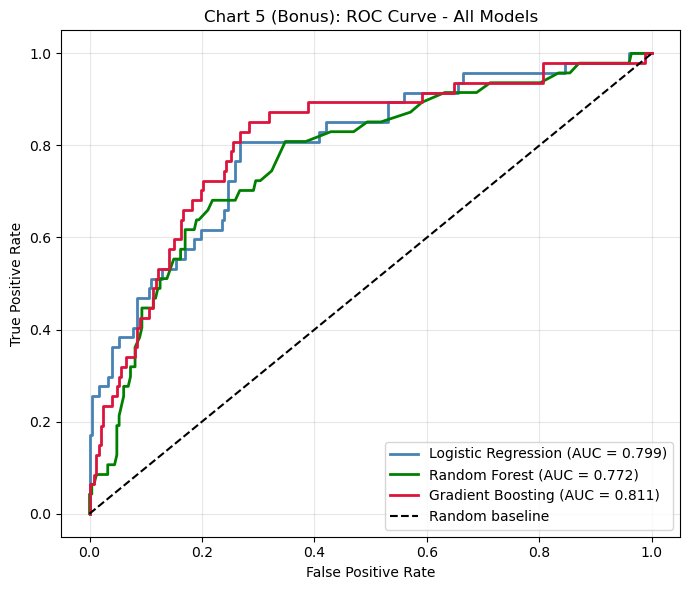

In [30]:
# Chart 5 (bonus) - ROC curves for all 3 models
fig, ax = plt.subplots(figsize=(7, 6))

for name, probs, color in [
    ('Logistic Regression', lr_probs, 'steelblue'),
    ('Random Forest', rf_probs, 'green'),
    ('Gradient Boosting', gb_probs, 'crimson')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', lw=2, color=color)

ax.plot([0,1],[0,1], 'k--', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Chart 5 (Bonus): ROC Curve - All Models')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/chart5_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 7 - HR Insights and Recommendations

**Top 3 factors that predict whether an employee will leave:**

1. **Monthly Income** - the biggest predictor. Employees earning below the median are significantly more likely to leave.
2. **Overtime** - employees required to work overtime have much higher exit rates. Burnout is real.
3. **Age and Total Working Years** - younger, early-career employees leave far more often than experienced ones.

**Which department/role should HR focus on?**

Sales Representatives have a 39.8% attrition rate - nearly 4 in 10 leave. This is the highest of any role. The Sales department overall (20.6%) and HR department (19%) also need attention. HR should start retention conversations specifically with Sales Reps who work overtime and have been at the company less than 2 years.

**Does salary alone explain attrition?**

No. While income is the strongest single predictor, overtime is almost equally important. Some employees earning decent salaries still leave because of workload and poor work-life balance. Giving a raise without fixing the overtime culture won't fully solve the problem.

**2 Concrete Recommendations:**

1. **Review overtime policies in Sales immediately.** Identify all Sales Representatives currently marked as working overtime and schedule 1-on-1 check-ins. Consider introducing a comp-time or overtime pay policy. This alone could reduce attrition in the highest-risk group.

2. **Build a structured first-year experience.** Since 33% of 0-2 year employees leave, the onboarding and early career phase is critical. Assign mentors to all new hires, do formal check-ins at 30, 60, and 90 days, and have a career conversation by month 3.

**Limitation:**

This model is based on past patterns. It cannot predict individual behavior with certainty, and it doesn't account for things like external job offers, personal reasons, or changes in the job market. HR should use this as a starting point for conversations, not as a definitive list of people who will leave. The model also has lower recall for identifying leavers (~62%) - meaning it still misses about 4 in 10 employees who eventually leave.


In [31]:
# final summary
print("Model Results Summary")
print("-" * 45)
print(comparison.to_string())
print()
print("Best model for catching at-risk employees: Logistic Regression (Recall = 0.617)")
print("Best model by AUC score: Gradient Boosting (AUC = 0.812)")
print()
print("Charts saved in ./charts/")

Model Results Summary
---------------------------------------------
                     Precision  Recall     F1  ROC-AUC
Model                                                 
Logistic Regression      0.341   0.617  0.439    0.799
Random Forest            0.571   0.085  0.148    0.772
Gradient Boosting        0.600   0.191  0.290    0.811

Best model for catching at-risk employees: Logistic Regression (Recall = 0.617)
Best model by AUC score: Gradient Boosting (AUC = 0.812)

Charts saved in ./charts/
